# Imports

In [23]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor, FasterRCNN
from torchvision.transforms.v2 import functional as F
from torchvision.transforms import v2
from torchvision import tv_tensors
import torch.utils.data
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import xml.etree.ElementTree as ET
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
import glob
import ssl
from collections import Counter
import pandas as pd

# Fix SSL certificate verification issue
ssl._create_default_https_context = ssl._create_unverified_context

# Check for GPU availability
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(torchmetrics.__version__)

Using device: cuda
PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
1.9.0


# Define Class Labels

In [2]:
# Class mapping for road signs
# 0 is reserved for background
CLASS_NAMES = {
    'background': 0,
    'pothole': 1
}

# Define colors for different classes
CLASS_COLORS = {
    'pothole': 'red',
    'background': 'gray'
}

# Reverse mapping for visualization
IDX_TO_CLASS = {v: k for k, v in CLASS_NAMES.items()}

NUM_CLASSES = len(CLASS_NAMES)  # Including background

print(f"Number of classes (including background): {NUM_CLASSES}")
print(f"Class mapping: {CLASS_NAMES}")

Number of classes (including background): 2
Class mapping: {'background': 0, 'pothole': 1}


# Loading in Dataset

In [3]:
data_dir = 'data/potholes'

In [4]:


class PotholeDataset(Dataset):
    """
    Custom Dataset for Pothole Detection.
    """
    def __init__(self, data_dir, class_mapping, transforms=None):
        self.data_dir = data_dir
        self.class_mapping = class_mapping
        self.transforms = transforms

        self.images = sorted(glob.glob(os.path.join(data_dir, '*.jpg')))

        self.annotations = []
        for img_path in self.images:
            basename = os.path.splitext(os.path.basename(img_path))[0]
            xml_path = os.path.join(self.data_dir, basename + '.xml')
            self.annotations.append(xml_path)

        valid_pairs = [(img, xml) for img, xml in zip(self.images, self.annotations)
                       if os.path.exists(xml)]
        self.images = [pair[0] for pair in valid_pairs]
        self.annotations = [pair[1] for pair in valid_pairs]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert('RGB')

        xml_path = self.annotations[idx]
        boxes, labels = parse_voc_xml(xml_path, self.class_mapping)

        # Filter invalid boxes (non-positive width/height) before tensor-izing
        valid_boxes = []
        valid_labels = []
        for i, box in enumerate(boxes):
            xmin, ymin, xmax, ymax = box
            if (xmax - xmin) > 1.0 and (ymax - ymin) > 1.0:
                valid_boxes.append(box)
                valid_labels.append(labels[i])

        if len(valid_boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.as_tensor(valid_boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(valid_labels, dtype=torch.int64)

        target = {}
        target['boxes'] = tv_tensors.BoundingBoxes(
            boxes_t, format='XYXY', canvas_size=(img.height, img.width)
        )
        target['labels'] = labels_t
        target['image_id'] = torch.tensor([idx])
        target['iscrowd'] = torch.zeros((len(boxes_t),), dtype=torch.int64)

        if self.transforms:
            img, target = self.transforms(img, target)
        else:
            img = F.to_image(img)
            img = F.to_dtype(img, torch.float32, scale=True)

        final_boxes = target['boxes']
        if final_boxes.numel() > 0:
            target['area'] = (final_boxes[:, 3] - final_boxes[:, 1]) * \
                             (final_boxes[:, 2] - final_boxes[:, 0])
        else:
            target['area'] = torch.zeros((0,), dtype=torch.float32)

        return img, target

In [5]:
def parse_voc_xml(xml_file, class_mapping):
    """
    Parse PASCAL VOC format XML annotation file.
    
    Args:
        xml_file: Path to XML annotation file
        class_mapping: Dictionary mapping class names to integers
    
    Returns:
        boxes: List of bounding boxes [xmin, ymin, xmax, ymax]
        labels: List of class labels
    """
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    boxes = []
    labels = []
    
    for obj in root.findall('object'):
        # Get class name
        class_name = obj.find('name').text.lower()
        
        # Map class name to label (default to 1 if not in mapping)
        label = class_mapping.get(class_name, 1)
        
        # Get bounding box coordinates
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)
    
    return boxes, labels

In [6]:
# Test the dataset
if os.path.exists(data_dir):
    dataset = PotholeDataset(data_dir, CLASS_NAMES)
    print(f"Dataset size: {len(dataset)} images")
    
    # Test loading one sample
    img, target = dataset[0]
    print(f"\nSample data:")
    print(f"Image shape: {img.shape}")
    print(f"Number of objects: {len(target['boxes'])}")
    print(f"Boxes shape: {target['boxes'].shape}")
    print(f"Labels: {target['labels'].tolist()}")
    print(f"Class names: {[IDX_TO_CLASS[l.item()] for l in target['labels']]}")

Dataset size: 665 images

Sample data:
Image shape: torch.Size([3, 720, 720])
Number of objects: 1
Boxes shape: torch.Size([1, 4])
Labels: [1]
Class names: ['pothole']


In [7]:
def visualize_sample(dataset, idx):
    """
    Visualize an image with bounding boxes.
    """
    img, target = dataset[idx]
    
    # Convert tensor to numpy for visualization
    img_np = img.permute(1, 2, 0).numpy()
    
    # Create figure
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img_np)
    
    # Draw bounding boxes
    boxes = target['boxes'].numpy()
    labels = target['labels'].numpy()
    
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin
        
        class_name = IDX_TO_CLASS.get(label, 'unknown')
        color = CLASS_COLORS.get(class_name, 'yellow')
        
        rect = patches.Rectangle((xmin, ymin), width, height, 
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin-5, class_name, color=color, fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(f"Sample {idx}: {len(boxes)} pothole(s) detected")
    ax.axis('off')
    plt.tight_layout()
    plt.show()


In [8]:
if os.path.exists(data_dir):
    dataset = PotholeDataset(data_dir, CLASS_NAMES)
    print(f"Dataset size: {len(dataset)} images")

Dataset size: 665 images


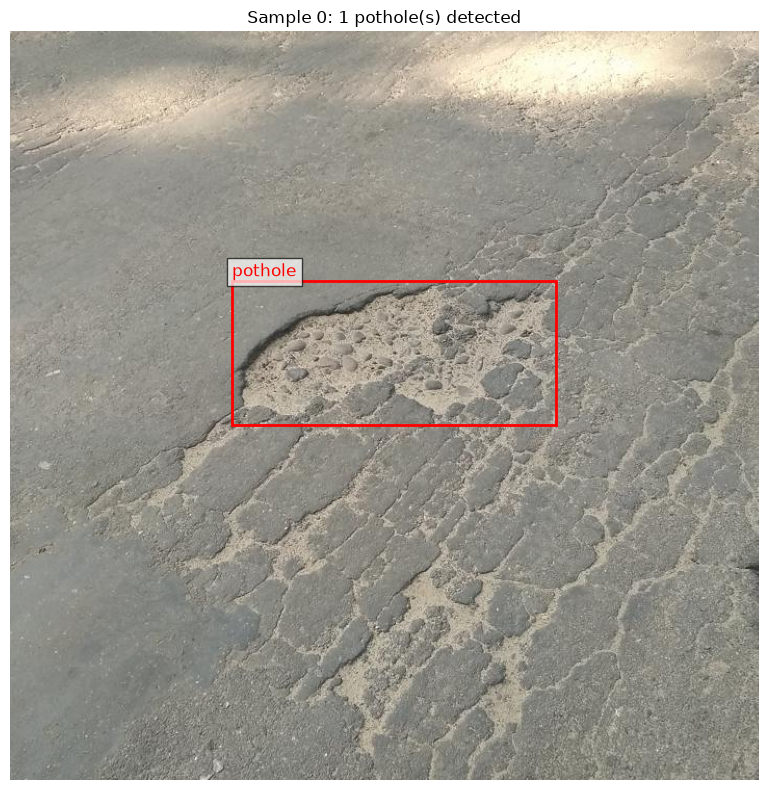

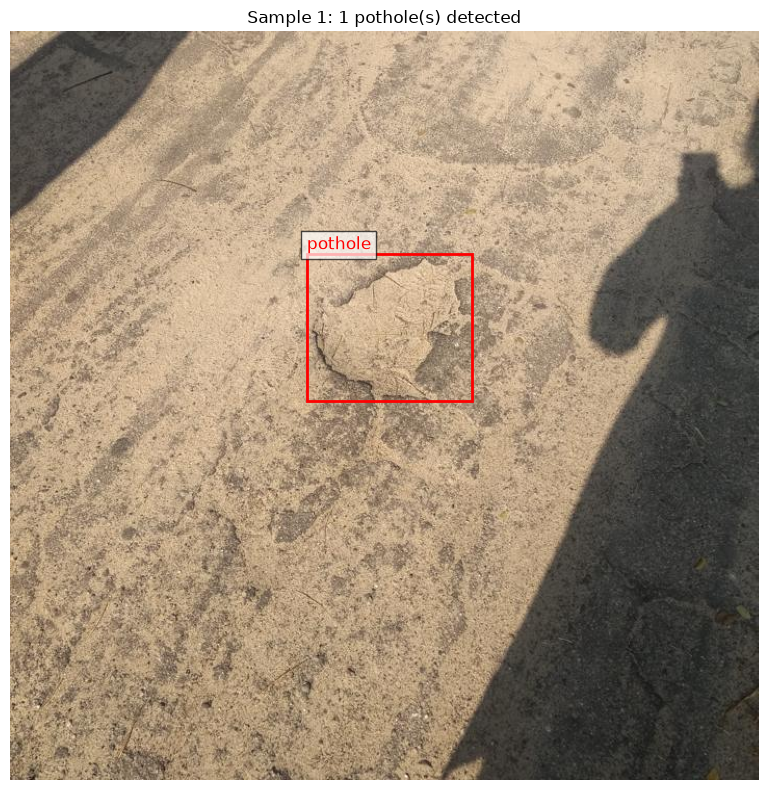

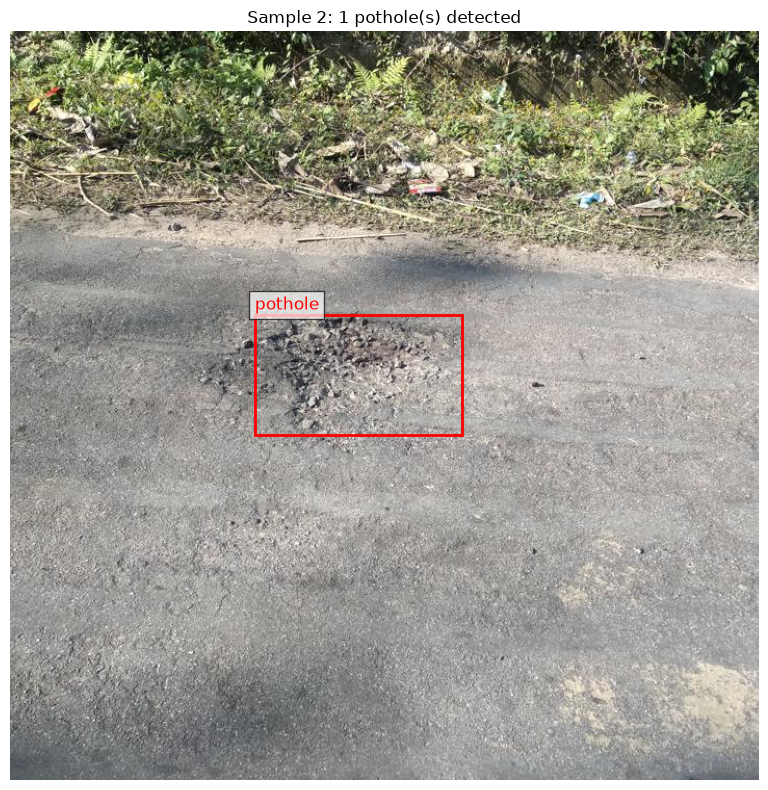

In [9]:

for i in range(min(3, len(dataset))):
    visualize_sample(dataset, i)

# Discussion

Cool, it looks like we're able to load in our images correctly, and bundle them with the corresponding labels

# Train test split

We'll want a train and validation set to use for training, and a completely untouched holdout set for the evaluation of the final model.

Even though the model is only seeing the train data, its early stopping, and its mAP are going to be calculated on the validation data. Moreover, we're going to run multiple experiments, and use their validation mAP to choose the best candidate. So in effect, we'll be fitting to the validation set with each experiment that we run. Consequently, our final performance on the validation set will be optimistic relative to how the model would perform on completely new data. The untouched holdout set helps us get an unbiased evaluation of our final model.

In [10]:

dataset_size = len(dataset)
full_train_size = int(0.8 * dataset_size)
test_size = dataset_size - full_train_size

train_size = int(0.8 * full_train_size)
valid_size = full_train_size - train_size


# Random split
torch.manual_seed(42)  # For reproducibility
train_dataset, valid_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, valid_size, test_size]
)

print(f"Total dataset size: {dataset_size}")
print(f"Training set size: {len(train_dataset)}")
print(f"Valid set size: {len(valid_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Total dataset size: 665
Training set size: 425
Valid set size: 107
Test set size: 133


# Modeling

* We'll be defining a few classes to help keep our experimentation ergonomic
    * First we'll have a DetectionPreprocessor whose job is to apply the right transforms to the train and valid/test data, and return dataloaders that can be ingested by the model.
    * We have an EarlyStopping class whose job is to monitor a scalar metric, in this case our val loss

* Then we get to the meat of the design choices
    * The ModifiedFasterRCNN class is a wrapper around a FasterRCNN object detection model.
        * It contains all the methods needed to train and evaluate a FasterRCNN model
        * The model can easily swap out the head, and unfreeze particular layers to allow fine tuning.
        * Though training and early stopping are based on val loss, the model computes mAP at user-defined intervals, and also each time the validation loss reaches a new minimum. This is a seemingly reasonable compromise between calculating mAP at every epoch (expensive), and assuming that the best mAP comes from the epoch with the best val loss (naive, since loss can improve with slight changes to bounding boxes, when the task we actually care about at the end of the day, pothole detection, may not be improving).
        * The class also instantiates its own early stopper, loss scheduler, optimizer, etc., reducing the risk of human error when organizing multiple experiments in a notebook.

In [11]:

def detection_collate_fn(batch):
    """Group a batch into (images_tuple, targets_tuple) instead of stacking.
    This is the format GeneralizedRCNN expects, and the only collation that
    works when images differ in size and box counts differ per image."""
    return tuple(zip(*batch))
 
 
class TransformedDetectionSubset(Dataset):
    """Applies a v2 (image, target) transform lazily, per access.
 
    Attaching transforms here — at the subset/view level — rather than on the
    underlying dataset is what lets train and val carry DIFFERENT transforms
    even when they came from one random_split of a single dataset. It also
    keeps augmentation re-sampled per epoch and leaves the source untouched.
 
    Assumes the wrapped subset yields (img, target) where target['boxes'] is a
    tv_tensors.BoundingBoxes so the v2 transform can keep boxes in sync.
    """
 
    def __init__(self, subset, transforms):
        self.subset = subset
        self.transforms = transforms
 
    def __len__(self):
        return len(self.subset)
 
    def __getitem__(self, i):
        img, target = self.subset[i]
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target
 
 
class DetectionPreprocessor:
    def __init__(self,
                 train_transforms=None,
                 test_transforms=None):
        # Minimal required pipeline: PIL -> float tensor in [0,1].
        # The model's internal transform handles normalize + resize, so we do
        # NOT include Normalize or Resize here.
        self.train_transforms = train_transforms or self._default_transforms()
        self.test_transforms = test_transforms or self._default_transforms()
 
    def _default_transforms(self):
        return v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
        ])
 
    def make_loader(self, view, **loader_kwargs):
        """Wrap a transformed view in a DataLoader, forcing the detection
        collate_fn unless the caller explicitly overrides it. Batching knobs
        (batch_size, shuffle, num_workers, ...) pass through."""
        loader_kwargs.setdefault('collate_fn', detection_collate_fn)
        return self.make_loader_raw(view, **loader_kwargs)
 
    def make_loader_raw(self, view, **loader_kwargs):
        return DataLoader(view, **loader_kwargs)
 
    def preprocess(self, dataset, is_train=True, **loader_kwargs):
        """Consume an already-split dataset/subset; return a ready DataLoader.
 
        is_train selects the transform pipeline (train may carry augmentation;
        test stays deterministic). There is no fitting step — this class is
        stateless.
        """
        transforms = self.train_transforms if is_train else self.test_transforms
        view = TransformedDetectionSubset(dataset, transforms)
        return self.make_loader(view, **loader_kwargs)


In [12]:
class EarlyStopping:
    """
    Early stopping to stop training when validation loss stops improving.
    """
    def __init__(self, patience=7, min_delta=0, verbose=True):
        """
        Args:
            patience: How many epochs to wait after last improvement
            min_delta: Minimum change to qualify as improvement
            verbose: Print messages
        """
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_weights = None
        
    def __call__(self, val_loss, model):
        """
        Check if training should stop
        
        Args:
            val_loss: Current validation loss
            model: Current model
            
        Returns:
            bool: Whether to stop training
        """
        if val_loss != val_loss:   # NaN check
            raise ValueError("val_loss is NaN — training diverged.")
        
        if self.best_loss is None:
            # First epoch
            self.best_loss = val_loss
            self.best_model_weights = copy.deepcopy(model.state_dict())
            if self.verbose:
                print(f"  → Early stopping: Baseline set (val_loss={val_loss:.4f})")
        elif val_loss > self.best_loss - self.min_delta:
            # No improvement
            self.counter += 1
            if self.verbose:
                print(f"  → Early stopping: {self.counter}/{self.patience} "
                      f"(val_loss={val_loss:.4f}, best={self.best_loss:.4f})")
            
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"\n  ⚠ Early stopping triggered! No improvement for {self.patience} epochs.")    
        else:

            # Improvement
            self.best_loss = val_loss
            self.best_model_weights = copy.deepcopy(model.state_dict())
            self.counter = 0
            if self.verbose:
                print(f"  → Early stopping: Improved! (val_loss={val_loss:.4f})")
        
        return self.early_stop

    def restore_best_weights(self, model):
        if self.best_model_weights is not None:
            model.load_state_dict(self.best_model_weights)
            if self.verbose:
                print(f"  → Restored best weights (val_loss={self.best_loss:.4f})")
        return model

    def reset_counter(self):
        self.counter = 0
        self.early_stop=False
        return self

    def reset_all_state(self):
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_weights = None
        return self
        

print("✓ Early stopping class defined")

✓ Early stopping class defined


In [13]:
class ModifiedFasterRCNN:
    def __init__(self,
                 detection_model,               # torchvision Faster R-CNN instance
                 optimizer,                     # optimizer CLASS, e.g. torch.optim.SGD
                 learning_scheduler,            # scheduler CLASS, e.g. ReduceLROnPlateau
                 early_stopper_class,           # EarlyStopping CLASS (built here)
                 preprocessor_class=None,       # DetectionPreprocessor CLASS (built here)
                 preprocessor=None,             # OR inject a ready instance (override)
                 early_stopper=None,            # OR inject a ready instance (override)
                 early_stopper_kwargs=None,     # kwargs for building the early stopper
                 preprocessor_kwargs=None,      # kwargs for building the preprocessor
                 loss_combiner=None):           # dict[str,Tensor]->scalar; default sum
        """
        Each wrapper OWNS a fresh set of collaborators. Pass CLASSES (plus
        optional kwargs) and the wrapper constructs its own optimizer,
        scheduler, early stopper, and preprocessor -- so running N experiments
        means tracking N models, not N x (optimizer, stopper, preprocessor)
        loose objects, and no collaborator is ever shared between experiments
        (which is what makes a fresh early stopper per model safe).
 
        Ready instances can still be injected via `preprocessor=` /
        `early_stopper=` as an escape hatch; an injected instance wins over the
        class-based construction.
        """
        self.model = detection_model
        self._optimizer = optimizer
        self._learning_scheduler = learning_scheduler
 
        # Early stopper: injected instance wins, else build a fresh one.
        if early_stopper is not None:
            self.early_stopper = early_stopper
        else:
            self.early_stopper = early_stopper_class(**(early_stopper_kwargs or {}))
 
        # Preprocessor: injected instance wins, else build one (default class
        # is DetectionPreprocessor if none supplied).
        if preprocessor is not None:
            self.preprocessor = preprocessor
        elif preprocessor_class is not None:
            self.preprocessor = preprocessor_class(**(preprocessor_kwargs or {}))
        else:
            self.preprocessor = DetectionPreprocessor(**(preprocessor_kwargs or {}))
 
        self.loss_combiner = loss_combiner if loss_combiner is not None \
            else (lambda loss_dict: sum(loss_dict.values()))
 
        self._replaced_predictor = False
        self.mode = None
        self.training_history = []
 
        # candidates for end-of-training mAP selection: every epoch that sets a
        # new best val loss gets snapshotted here.
        self._loss_incumbent_snapshots = []   # list of (epoch, state_dict, val_loss)
 
    # ------------------------------------------------------------------ #
    # mode handling
    # ------------------------------------------------------------------ #
    def set_model_mode(self, mode):
        """'train' or 'eval'. For detection this changes the model's OUTPUT
        TYPE (losses vs detections), not just BN/dropout behavior."""
        if mode == 'train':
            self.model.train()
        elif mode == 'eval':
            self.model.eval()
        else:
            raise ValueError(f"mode must be 'train' or 'eval'. Got: {mode}")
        self.mode = mode
        return self
 
    # ------------------------------------------------------------------ #
    # head replacement (box predictor swap)
    # ------------------------------------------------------------------ #
    def replace_box_predictor(self, num_classes):
        """Replace the detection head's final classification + box-regression
        layers, sized to num_classes. num_classes must INCLUDE background
        (e.g. 1 pothole + background = 2). in_features is read from the
        existing predictor, never passed in."""
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
        self._replaced_predictor = True
        return self
 
    # ------------------------------------------------------------------ #
    # freezing (RPN only; backbone handled at construction)
    # ------------------------------------------------------------------ #
    def set_component_trainable(self, component_prefix, trainable):
        """Toggle requires_grad for all params whose name starts with
        component_prefix (e.g. 'rpn', 'roi_heads.box_predictor')."""
        for name, p in self.model.named_parameters():
            if name.startswith(component_prefix):
                p.requires_grad = trainable
        return self
 
    def freeze_rpn(self):
        return self.set_component_trainable('rpn', False)
 
    def unfreeze_rpn(self):
        return self.set_component_trainable('rpn', True)
 
    def trainable_parameters(self):
        return [p for p in self.model.parameters() if p.requires_grad]
 
    # ------------------------------------------------------------------ #
    # optimizer / scheduler
    # ------------------------------------------------------------------ #
    def instantiate_optimizer(self, parameters, **kwargs):
        self.optimizer = self._optimizer(parameters, **kwargs)
        return self
 
    def instantiate_learning_scheduler(self, **kwargs):
        self.learning_scheduler = self._learning_scheduler(self.optimizer, **kwargs)
        return self
 
    # ------------------------------------------------------------------ #
    # dataloader construction (delegates to the owned preprocessor)
    # ------------------------------------------------------------------ #
    def build_loader(self, dataset, is_train, **loader_kwargs):
        """Turn one split (dataset/subset) into a DataLoader via the owned
        preprocessor. is_train selects the transform pipeline and is a sensible
        default for shuffle (train shuffles, eval doesn't) unless overridden."""
        loader_kwargs.setdefault('shuffle', is_train)
        return self.preprocessor.preprocess(dataset, is_train=is_train, **loader_kwargs)
 
    def build_loaders(self, train_dataset, val_dataset, test_dataset=None,
                      **loader_kwargs):
        """Build train/val (and optional test) loaders in one call. Batching
        kwargs (batch_size, num_workers, ...) apply to all; shuffle is set per
        split (True for train, False for val/test). Returns a dict of loaders."""
        loaders = {
            'train': self.build_loader(train_dataset, is_train=True, **loader_kwargs),
            'val':   self.build_loader(val_dataset,   is_train=False, **loader_kwargs),
        }
        if test_dataset is not None:
            loaders['test'] = self.build_loader(test_dataset, is_train=False,
                                                **loader_kwargs)
        return loaders
 
    # ------------------------------------------------------------------ #
    # device
    # ------------------------------------------------------------------ #
    def to(self, device):
        self.model.to(device)
        return self
 
    # ------------------------------------------------------------------ #
    # training
    # ------------------------------------------------------------------ #
    def _train_one_epoch(self, train_loader, device, epoch=None, epochs=None,
                         print_every=20):
        """Real training pass: train() mode, gradients on. Model returns a loss
        dict; combine and backprop. Returns running average combined loss.
 
        Prints within-epoch progress every `print_every` batches so a slow
        detection epoch is visibly alive rather than apparently hung. Set
        print_every=0 to silence within-epoch output."""
        self.set_model_mode('train')
        running = 0.0
        n = 0
        n_batches = len(train_loader)
        epoch_tag = f"Epoch {epoch + 1}/{epochs} " if epoch is not None else ""
 
        for batch_idx, (images, targets) in enumerate(train_loader):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
 
            self.optimizer.zero_grad()
            loss_dict = self.model(images, targets)   # train mode -> losses
            loss = self.loss_combiner(loss_dict)
            loss.backward()
            self.optimizer.step()
 
            running += loss.item()
            n += 1
 
            if print_every and (batch_idx + 1) % print_every == 0:
                # also surface the individual loss components -- useful for
                # spotting e.g. an exploding box-reg loss early
                parts = " ".join(f"{k}={v.item():.3f}" for k, v in loss_dict.items())
                print(f"  {epoch_tag}batch {batch_idx + 1}/{n_batches} "
                      f"| loss {running / n:.4f} | {parts}", flush=True)
 
        return running / max(n, 1)
 
    def training_loop(self,
                      train_loader,
                      val_loader,
                      device,
                      epochs=10,
                      early_stopping='use',
                      calculate_map_interval=None,   # None => no periodic mAP diagnostic
                      print_every=20,                # within-epoch batch print cadence
                      **kwargs):
        import time
 
        optimizer_kwargs = {k.split('__', 1)[1]: v for k, v in kwargs.items()
                            if k.startswith('optimizer__')}
        scheduler_kwargs = {k.split('__', 1)[1]: v for k, v in kwargs.items()
                            if k.startswith('scheduler__')}
 
        self.to(device)
        self.instantiate_optimizer(self.trainable_parameters(), **optimizer_kwargs)
        self.instantiate_learning_scheduler(**scheduler_kwargs)
 
        if early_stopping == 'reset':
            self.early_stopper.reset_all_state()
        elif early_stopping == 'soft':
            self.early_stopper.reset_counter()
 
        n_trainable = sum(p.numel() for p in self.trainable_parameters())
        print("=" * 70)
        print(f"Starting detection training for {epochs} epoch(s)")
        print(f"  trainable params: {n_trainable:,} | "
              f"train batches/epoch: {len(train_loader)} | "
              f"device: {device}")
        print("=" * 70, flush=True)
 
        for epoch in range(epochs):
            t0 = time.time()
            print(f"\nEpoch {epoch + 1}/{epochs}", flush=True)
 
            train_loss = self._train_one_epoch(
                train_loader, device, epoch=epoch, epochs=epochs,
                print_every=print_every)
            val_loss = self.compute_val_loss(val_loader, device)
 
            self.learning_scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']
 
            metrics = {
                'epoch': len(self.training_history),
                'epoch_of_current_run': epoch,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'learning_rate': current_lr,
            }
 
            # periodic mAP diagnostic only (does NOT drive selection)
            map_str = ""
            if calculate_map_interval and (epoch + 1) % calculate_map_interval == 0:
                val_map = self.evaluate_detections(val_loader, device)
                metrics['val_map'] = val_map
                map_str = f" | val_mAP {val_map:.4f}"
 
            self.training_history.append(metrics)
 
            # snapshot loss-incumbents for end-of-training mAP selection.
            # (the early stopper independently tracks its own best-loss weights)
            is_new_best = (self.early_stopper.best_loss is None
                           or val_loss < self.early_stopper.best_loss)
            star = "  <- new best val_loss" if is_new_best else ""
            if is_new_best:
                self._snapshot_loss_incumbent(epoch, val_loss)
 
            elapsed = time.time() - t0
            print(f"  epoch {epoch + 1} done in {elapsed:.1f}s | "
                  f"train_loss {train_loss:.4f} | val_loss {val_loss:.4f}"
                  f"{map_str} | lr {current_lr:.2e}{star}", flush=True)
 
            if early_stopping != 'off':
                if self.early_stopper(val_loss, self.model):
                    print(f"\nEarly stopping triggered at epoch {epoch + 1}", flush=True)
                    break
 
        print("\n" + "=" * 70)
        print("Training complete.")
        print("=" * 70, flush=True)
        return self
 
    # ------------------------------------------------------------------ #
    # the two evaluation paths (mutually exclusive model modes)
    # ------------------------------------------------------------------ #
    def compute_val_loss(self, val_loader, device):
        """Cheap early-stopping signal. Needs train() mode (to get losses) +
        no_grad() (to not learn). Targets go TO THE MODEL.
 
        NB: train() would normally drift BatchNorm running stats, but the
        detection backbone uses FrozenBatchNorm by default, so there are no
        stats to corrupt. If a trainable-BN backbone is ever used, BN would
        need to be forced to eval here."""
        self.set_model_mode('train')
        running = 0.0
        n = 0
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                loss_dict = self.model(images, targets)
                running += self.loss_combiner(loss_dict).item()
                n += 1
        return running / max(n, 1)
 
    def evaluate_detections(self, loader, device, return_full=False):
        """Expensive mAP path. Needs eval() mode (to get detections). Model is
        called WITHOUT targets; targets go TO THE METRIC, not the model.
 
        Uses torchmetrics MeanAveragePrecision. Returns COCO-style mAP@[.5:.95]
        by default (a single float); pass return_full=True to get the whole
        result dict, which includes map_50 and map_75 -- the AP@0.5 vs AP@0.75
        split that reads as classification-vs-localization quality.
 
        Format contract (the part that fails silently if wrong):
          predictions: list of dicts with 'boxes', 'scores', 'labels'
          targets:     list of dicts with 'boxes', 'labels'  (NO scores)
        Both boxes are [N,4] xyxy. The metric wants CPU tensors, so predictions
        and targets are moved off-device before being handed over.
        """
        from torchmetrics.detection.mean_ap import MeanAveragePrecision
 
        self.set_model_mode('eval')            # eval() -> model returns detections
        metric = MeanAveragePrecision(box_format='xyxy')
 
        with torch.no_grad():
            for images, targets in loader:
                images = [img.to(device) for img in images]
                preds = self.model(images)     # no targets -> list of detection dicts
 
                # predictions: keep only the three keys the metric expects, on CPU
                preds_cpu = [{
                    'boxes': p['boxes'].detach().cpu(),
                    'scores': p['scores'].detach().cpu(),
                    'labels': p['labels'].detach().cpu(),
                } for p in preds]
 
                # targets: boxes + labels only (NO scores), on CPU. Note the
                # boxes may be a tv_tensors.BoundingBoxes subclass; plain-tensor
                # them so the metric doesn't choke on the wrapper.
                targets_cpu = [{
                    'boxes': torch.as_tensor(t['boxes']).detach().cpu(),
                    'labels': t['labels'].detach().cpu(),
                } for t in targets]
 
                metric.update(preds_cpu, targets_cpu)
 
        result = metric.compute()
        if return_full:
            return {k: (v.item() if torch.is_tensor(v) and v.ndim == 0 else v)
                    for k, v in result.items()}
        return result['map'].item()
 
    # ------------------------------------------------------------------ #
    # prediction
    # ------------------------------------------------------------------ #
    def predict(self, images, device):
        """eval() mode; returns list of detection dicts (boxes/labels/scores)."""
        self.set_model_mode('eval')
        with torch.no_grad():
            images = [img.to(device) for img in images]
            return self.model(images)
 
    # ------------------------------------------------------------------ #
    # end-of-training mAP-based selection over saved loss-incumbents
    # ------------------------------------------------------------------ #
    def _snapshot_loss_incumbent(self, epoch, val_loss):
        snapshot = {k: v.detach().cpu().clone()
                    for k, v in self.model.state_dict().items()}
        self._loss_incumbent_snapshots.append((epoch, snapshot, val_loss))
        return self
 
    def select_best_by_map(self, loader, device):
        """After training: compute mAP on each saved loss-incumbent snapshot,
        restore the weights of the best. Ties break toward the EARLIER
        (leaner / less-trained) checkpoint.
 
        Depends on evaluate_detections returning a comparable scalar."""
        if not self._loss_incumbent_snapshots:
            return self
 
        best_map = None
        best_state = None
        best_epoch = None
        for epoch, state, _ in self._loss_incumbent_snapshots:
            self.model.load_state_dict(state)
            score = self.evaluate_detections(loader, device)   # scalar mAP
            # strict > keeps the FIRST (earliest) on ties -> leaner checkpoint
            if best_map is None or score > best_map:
                best_map = score
                best_state = state
                best_epoch = epoch
        if best_state is not None:
            self.model.load_state_dict(best_state)
            print(f"Selected checkpoint from epoch {best_epoch} (mAP={best_map:.4f})")
        return self
 


In [14]:
device

device(type='cuda')

In [15]:
DETECTION_MODEL = fasterrcnn_resnet50_fpn(weights='DEFAULT', trainable_backbone_layers=3)
PREPROCESSOR = DetectionPreprocessor
OPTIMIZER = torch.optim.SGD
SCHEDULER = ReduceLROnPlateau
EARLY_STOPPER = EarlyStopping

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/jovyan/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:07<00:00, 21.0MB/s] 


In [16]:
model = ModifiedFasterRCNN(
        detection_model=DETECTION_MODEL,
        optimizer=OPTIMIZER,
        learning_scheduler=SCHEDULER,
        early_stopper_class=EARLY_STOPPER,
        early_stopper_kwargs={'patience': 8},
    )

In [17]:
model.replace_box_predictor(num_classes=2)

In [18]:
loaders = model.build_loaders(train_dataset, valid_dataset, test_dataset, batch_size=4, num_workers=2)

In [19]:
model.training_loop(train_loader=loaders['train'],
                    val_loader=loaders['val'],
                    device=device,
                    epochs=100,
                    optimizer__lr=0.005, 
                    optimizer__momentum=0.9,
                    optimizer__weight_decay=0.0005,
                    scheduler__mode='min', 
                    scheduler__patience=3,
                    calculate_map_interval=5,
                    print_every=5)

Starting detection training for 100 epoch(s)
  trainable params: 41,076,761 | train batches/epoch: 107 | device: cuda

Epoch 1/100
  Epoch 1/100 batch 5/107 | loss 0.6250 | loss_classifier=0.170 loss_box_reg=0.163 loss_objectness=0.115 loss_rpn_box_reg=0.017
  Epoch 1/100 batch 10/107 | loss 0.5372 | loss_classifier=0.164 loss_box_reg=0.170 loss_objectness=0.069 loss_rpn_box_reg=0.061
  Epoch 1/100 batch 15/107 | loss 0.5145 | loss_classifier=0.148 loss_box_reg=0.147 loss_objectness=0.063 loss_rpn_box_reg=0.014
  Epoch 1/100 batch 20/107 | loss 0.4900 | loss_classifier=0.111 loss_box_reg=0.118 loss_objectness=0.055 loss_rpn_box_reg=0.011
  Epoch 1/100 batch 25/107 | loss 0.4502 | loss_classifier=0.197 loss_box_reg=0.264 loss_objectness=0.060 loss_rpn_box_reg=0.019
  Epoch 1/100 batch 30/107 | loss 0.4310 | loss_classifier=0.132 loss_box_reg=0.195 loss_objectness=0.070 loss_rpn_box_reg=0.020
  Epoch 1/100 batch 35/107 | loss 0.4301 | loss_classifier=0.185 loss_box_reg=0.266 loss_objectn

In [20]:
device

device(type='cuda')

In [21]:
model.select_best_by_map(loaders['val'], device)
                                                                          

Selected checkpoint from epoch 2 (mAP=0.4726)


In [24]:
model_curves_df = pd.DataFrame(model.training_history)

In [25]:
model_curves_df

,epoch,epoch_of_current_run,train_loss,val_loss,learning_rate,val_map
0,0,0,0.359046,0.301835,0.00500,NaN
1,1,1,0.268528,0.249521,0.00500,NaN
2,2,2,0.223102,0.248714,0.00500,NaN
3,3,3,0.191230,0.260742,0.00500,NaN
4,4,4,0.152138,0.257587,0.00500,0.480686
5,5,5,0.128000,0.273858,0.00500,NaN
6,6,6,0.113023,0.284835,0.00050,NaN
7,7,7,0.087421,0.281080,0.00050,NaN
8,8,8,0.079585,0.281382,0.00050,NaN
9,9,9,0.075002,0.285618,0.00050,0.496156


<Axes: xlabel='epoch'>

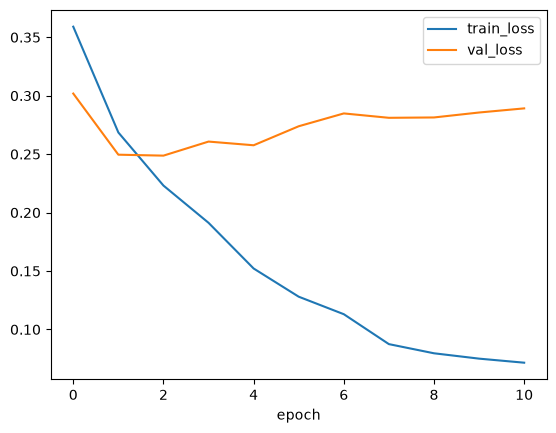

In [28]:
model_curves_df.plot(x='epoch', y=['train_loss', 'val_loss'])

# Discussion

* It looks like the model begins overfitting pretty quickly! Let's think about regularization. The first candidate is making the backbone untrainable - the default is making the top 3 layers trainable.
* I also think there's some chance we're just dealing with really small data here. Maybe augmentation will help.
* Also, look at what happens with mAP! Even though val loss is increasing, suggesting overfitting, mAP is actually increasing, which is good. However, the model code is only able to pick the best mAP from the epochs which reset the best val loss. Something to keep in mind and potentially improve.

In [30]:
REGULARIZED_DETECTION_MODEL = fasterrcnn_resnet50_fpn(weights='DEFAULT', trainable_backbone_layers=0)


In [31]:
regularized_model = ModifiedFasterRCNN(
        detection_model=REGULARIZED_DETECTION_MODEL,
        optimizer=OPTIMIZER,
        learning_scheduler=SCHEDULER,
        early_stopper_class=EARLY_STOPPER,
        early_stopper_kwargs={'patience': 8},
    )

In [32]:
regularized_model.replace_box_predictor(num_classes=2)

In [34]:
regularized_loaders = regularized_model.build_loaders(train_dataset, valid_dataset, test_dataset, batch_size=4, num_workers=2)

In [35]:
regularized_model.training_loop(train_loader=regularized_loaders['train'],
                    val_loader=regularized_loaders['val'],
                    device=device,
                    epochs=100,
                    optimizer__lr=0.005, 
                    optimizer__momentum=0.9,
                    optimizer__weight_decay=0.0005,
                    scheduler__mode='min', 
                    scheduler__patience=3,
                    calculate_map_interval=5,
                    print_every=5)

Starting detection training for 100 epoch(s)
  trainable params: 17,844,249 | train batches/epoch: 107 | device: cuda

Epoch 1/100
  Epoch 1/100 batch 5/107 | loss 0.6988 | loss_classifier=0.202 loss_box_reg=0.084 loss_objectness=0.126 loss_rpn_box_reg=0.011
  Epoch 1/100 batch 10/107 | loss 0.6218 | loss_classifier=0.444 loss_box_reg=0.197 loss_objectness=0.062 loss_rpn_box_reg=0.058
  Epoch 1/100 batch 15/107 | loss 0.5442 | loss_classifier=0.185 loss_box_reg=0.169 loss_objectness=0.041 loss_rpn_box_reg=0.007
  Epoch 1/100 batch 20/107 | loss 0.5153 | loss_classifier=0.219 loss_box_reg=0.158 loss_objectness=0.101 loss_rpn_box_reg=0.029
  Epoch 1/100 batch 25/107 | loss 0.4892 | loss_classifier=0.117 loss_box_reg=0.074 loss_objectness=0.033 loss_rpn_box_reg=0.009
  Epoch 1/100 batch 30/107 | loss 0.4767 | loss_classifier=0.139 loss_box_reg=0.166 loss_objectness=0.068 loss_rpn_box_reg=0.038
  Epoch 1/100 batch 35/107 | loss 0.4825 | loss_classifier=0.135 loss_box_reg=0.126 loss_objectn

In [37]:
regularized_model.select_best_by_map(regularized_loaders['val'], device)

Selected checkpoint from epoch 8 (mAP=0.3248)


In [38]:
regularized_model_curves_df = pd.DataFrame(regularized_model.training_history)

In [41]:
regularized_model_curves_df

,epoch,epoch_of_current_run,train_loss,val_loss,learning_rate,val_map
0,0,0,0.411175,0.318191,0.00500,NaN
1,1,1,0.321913,0.312987,0.00500,NaN
2,2,2,0.303445,0.286108,0.00500,NaN
3,3,3,0.284549,0.281760,0.00500,NaN
4,4,4,0.273202,0.280871,0.00500,0.285394
5,5,5,0.269032,0.283744,0.00500,NaN
6,6,6,0.257388,0.270071,0.00500,NaN
7,7,7,0.242538,0.275038,0.00500,NaN
8,8,8,0.237359,0.267307,0.00500,NaN
9,9,9,0.230484,0.272043,0.00500,0.321674


<Axes: xlabel='epoch'>

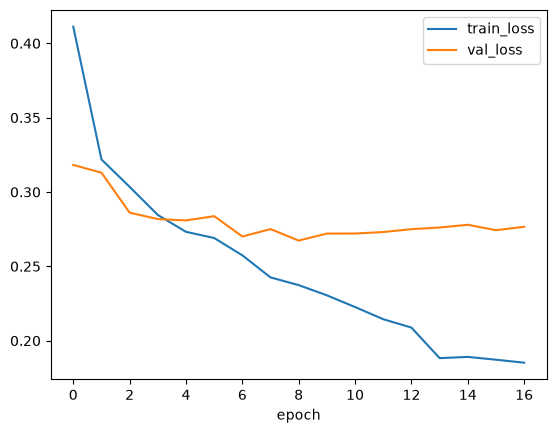

In [40]:
regularized_model_curves_df.plot(x='epoch', y=['train_loss', 'val_loss'])

# Discussion

* In response to overfitting concerns, we froze the top layers of the backbone, which also freezes the FPN.
* However, this appears to have been an overreaction - the winning val mAP is much worse than the previous experiment's
* The model is programmed to remember the epochs that led to each new minimum val loss, and select the epoch from them which has the best val mAP score. Separately, we track mAP every few epochs, and in both of our experiments we're getting some better val mAPs than those in the candidate epochs. Since we're already tracking mAP every few epochs, we should remember those as well, and be able to choose from them at the end.

# Let's make a couple improvements to the model.
* The model can now select best mAP from those computed at intervals
* The model can also easily calculate mAP50, mAP75, which can help with interpreting the mAP score.

In [45]:

class ModifiedFasterRCNN:
    def __init__(self,
                 detection_model,               # torchvision Faster R-CNN instance
                 optimizer,                     # optimizer CLASS, e.g. torch.optim.SGD
                 learning_scheduler,            # scheduler CLASS, e.g. ReduceLROnPlateau
                 early_stopper_class,           # EarlyStopping CLASS (built here)
                 preprocessor_class=None,       # DetectionPreprocessor CLASS (built here)
                 preprocessor=None,             # OR inject a ready instance (override)
                 early_stopper=None,            # OR inject a ready instance (override)
                 early_stopper_kwargs=None,     # kwargs for building the early stopper
                 preprocessor_kwargs=None,      # kwargs for building the preprocessor
                 loss_combiner=None):           # dict[str,Tensor]->scalar; default sum
        """
        Each wrapper OWNS a fresh set of collaborators. Pass CLASSES (plus
        optional kwargs) and the wrapper constructs its own optimizer,
        scheduler, early stopper, and preprocessor -- so running N experiments
        means tracking N models, not N x (optimizer, stopper, preprocessor)
        loose objects, and no collaborator is ever shared between experiments
        (which is what makes a fresh early stopper per model safe).
 
        Ready instances can still be injected via `preprocessor=` /
        `early_stopper=` as an escape hatch; an injected instance wins over the
        class-based construction.
        """
        self.model = detection_model
        self._optimizer = optimizer
        self._learning_scheduler = learning_scheduler
 
        # Early stopper: injected instance wins, else build a fresh one.
        if early_stopper is not None:
            self.early_stopper = early_stopper
        else:
            self.early_stopper = early_stopper_class(**(early_stopper_kwargs or {}))
 
        # Preprocessor: injected instance wins, else build one (default class
        # is DetectionPreprocessor if none supplied).
        if preprocessor is not None:
            self.preprocessor = preprocessor
        elif preprocessor_class is not None:
            self.preprocessor = preprocessor_class(**(preprocessor_kwargs or {}))
        else:
            self.preprocessor = DetectionPreprocessor(**(preprocessor_kwargs or {}))
 
        self.loss_combiner = loss_combiner if loss_combiner is not None \
            else (lambda loss_dict: sum(loss_dict.values()))
 
        self._replaced_predictor = False
        self.mode = None
        self.training_history = []
 
        # candidates for end-of-training mAP selection: every epoch that sets a
        # new best val loss gets snapshotted here.
        self._loss_incumbent_snapshots = []   # list of (epoch, state_dict, val_loss)
 
        # best snapshot seen during interval-mAP diagnostics (mAP incumbents).
        # None until an interval-mAP evaluation beats the prior best. These are
        # ALSO candidates in select_best_by_map, which closes the hole where the
        # best-mAP epoch is not a best-val-loss epoch.
        self._best_map_snapshot = None        # (epoch, state_dict, val_map) or None
 
    # ------------------------------------------------------------------ #
    # mode handling
    # ------------------------------------------------------------------ #
    def set_model_mode(self, mode):
        """'train' or 'eval'. For detection this changes the model's OUTPUT
        TYPE (losses vs detections), not just BN/dropout behavior."""
        if mode == 'train':
            self.model.train()
        elif mode == 'eval':
            self.model.eval()
        else:
            raise ValueError(f"mode must be 'train' or 'eval'. Got: {mode}")
        self.mode = mode
        return self
 
    # ------------------------------------------------------------------ #
    # head replacement (box predictor swap)
    # ------------------------------------------------------------------ #
    def replace_box_predictor(self, num_classes):
        """Replace the detection head's final classification + box-regression
        layers, sized to num_classes. num_classes must INCLUDE background
        (e.g. 1 pothole + background = 2). in_features is read from the
        existing predictor, never passed in."""
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
        self._replaced_predictor = True
        return self
 
    # ------------------------------------------------------------------ #
    # freezing (RPN only; backbone handled at construction)
    # ------------------------------------------------------------------ #
    def set_component_trainable(self, component_prefix, trainable):
        """Toggle requires_grad for all params whose name starts with
        component_prefix (e.g. 'rpn', 'roi_heads.box_predictor')."""
        for name, p in self.model.named_parameters():
            if name.startswith(component_prefix):
                p.requires_grad = trainable
        return self
 
    def freeze_rpn(self):
        return self.set_component_trainable('rpn', False)
 
    def unfreeze_rpn(self):
        return self.set_component_trainable('rpn', True)
 
    def trainable_parameters(self):
        return [p for p in self.model.parameters() if p.requires_grad]
 
    # ------------------------------------------------------------------ #
    # optimizer / scheduler
    # ------------------------------------------------------------------ #
    def instantiate_optimizer(self, parameters, **kwargs):
        self.optimizer = self._optimizer(parameters, **kwargs)
        return self
 
    def instantiate_learning_scheduler(self, **kwargs):
        self.learning_scheduler = self._learning_scheduler(self.optimizer, **kwargs)
        return self
 
    # ------------------------------------------------------------------ #
    # dataloader construction (delegates to the owned preprocessor)
    # ------------------------------------------------------------------ #
    def build_loader(self, dataset, is_train, **loader_kwargs):
        """Turn one split (dataset/subset) into a DataLoader via the owned
        preprocessor. is_train selects the transform pipeline and is a sensible
        default for shuffle (train shuffles, eval doesn't) unless overridden."""
        loader_kwargs.setdefault('shuffle', is_train)
        return self.preprocessor.preprocess(dataset, is_train=is_train, **loader_kwargs)
 
    def build_loaders(self, train_dataset, val_dataset, test_dataset=None,
                      **loader_kwargs):
        """Build train/val (and optional test) loaders in one call. Batching
        kwargs (batch_size, num_workers, ...) apply to all; shuffle is set per
        split (True for train, False for val/test). Returns a dict of loaders."""
        loaders = {
            'train': self.build_loader(train_dataset, is_train=True, **loader_kwargs),
            'val':   self.build_loader(val_dataset,   is_train=False, **loader_kwargs),
        }
        if test_dataset is not None:
            loaders['test'] = self.build_loader(test_dataset, is_train=False,
                                                **loader_kwargs)
        return loaders
 
    # ------------------------------------------------------------------ #
    # device
    # ------------------------------------------------------------------ #
    def to(self, device):
        self.model.to(device)
        return self
 
    # ------------------------------------------------------------------ #
    # training
    # ------------------------------------------------------------------ #
    def _train_one_epoch(self, train_loader, device, epoch=None, epochs=None,
                         print_every=20):
        """Real training pass: train() mode, gradients on. Model returns a loss
        dict; combine and backprop. Returns running average combined loss.
 
        Prints within-epoch progress every `print_every` batches so a slow
        detection epoch is visibly alive rather than apparently hung. Set
        print_every=0 to silence within-epoch output."""
        self.set_model_mode('train')
        running = 0.0
        n = 0
        n_batches = len(train_loader)
        epoch_tag = f"Epoch {epoch + 1}/{epochs} " if epoch is not None else ""
 
        for batch_idx, (images, targets) in enumerate(train_loader):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
 
            self.optimizer.zero_grad()
            loss_dict = self.model(images, targets)   # train mode -> losses
            loss = self.loss_combiner(loss_dict)
            loss.backward()
            self.optimizer.step()
 
            running += loss.item()
            n += 1
 
            if print_every and (batch_idx + 1) % print_every == 0:
                # also surface the individual loss components -- useful for
                # spotting e.g. an exploding box-reg loss early
                parts = " ".join(f"{k}={v.item():.3f}" for k, v in loss_dict.items())
                print(f"  {epoch_tag}batch {batch_idx + 1}/{n_batches} "
                      f"| loss {running / n:.4f} | {parts}", flush=True)
 
        return running / max(n, 1)
 
    def training_loop(self,
                      train_loader,
                      val_loader,
                      device,
                      epochs=10,
                      early_stopping='use',
                      calculate_map_interval=None,   # None => no periodic mAP diagnostic
                      full_map_metrics=False,        # log map_50/map_75 too, not just map
                      print_every=20,                # within-epoch batch print cadence
                      **kwargs):
        import time
 
        optimizer_kwargs = {k.split('__', 1)[1]: v for k, v in kwargs.items()
                            if k.startswith('optimizer__')}
        scheduler_kwargs = {k.split('__', 1)[1]: v for k, v in kwargs.items()
                            if k.startswith('scheduler__')}
 
        self.to(device)
        self.instantiate_optimizer(self.trainable_parameters(), **optimizer_kwargs)
        self.instantiate_learning_scheduler(**scheduler_kwargs)
 
        if early_stopping == 'reset':
            self.early_stopper.reset_all_state()
        elif early_stopping == 'soft':
            self.early_stopper.reset_counter()
 
        n_trainable = sum(p.numel() for p in self.trainable_parameters())
        print("=" * 70)
        print(f"Starting detection training for {epochs} epoch(s)")
        print(f"  trainable params: {n_trainable:,} | "
              f"train batches/epoch: {len(train_loader)} | "
              f"device: {device}")
        print("=" * 70, flush=True)
 
        for epoch in range(epochs):
            t0 = time.time()
            print(f"\nEpoch {epoch + 1}/{epochs}", flush=True)
 
            train_loss = self._train_one_epoch(
                train_loader, device, epoch=epoch, epochs=epochs,
                print_every=print_every)
            val_loss = self.compute_val_loss(val_loader, device)
 
            self.learning_scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']
 
            metrics = {
                'epoch': len(self.training_history),
                'epoch_of_current_run': epoch,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'learning_rate': current_lr,
            }
 
            # periodic mAP diagnostic (also feeds candidate selection now)
            map_str = ""
            if calculate_map_interval and (epoch + 1) % calculate_map_interval == 0:
                result = self.evaluate_detections(
                    val_loader, device, return_full=full_map_metrics)
 
                if full_map_metrics:
                    # result is the full dict; pull the headline + interpretable ones
                    val_map = result['map'] if not torch.is_tensor(result['map']) \
                        else result['map'].item()
                    metrics['val_map'] = val_map
                    for key in ('map_50', 'map_75'):
                        if key in result:
                            v = result[key]
                            metrics[f'val_{key}'] = v.item() if torch.is_tensor(v) else v
                    map_str = (f" | val_mAP {val_map:.4f}"
                               f" (map_50 {metrics.get('val_map_50', float('nan')):.4f})")
                else:
                    val_map = result   # scalar
                    metrics['val_map'] = val_map
                    map_str = f" | val_mAP {val_map:.4f}"
 
                # keep the best interval-mAP snapshot as a selection candidate.
                # Comparison always uses the headline `map`, whatever we logged.
                if (self._best_map_snapshot is None
                        or val_map > self._best_map_snapshot[2]):
                    snap = {k: v.detach().cpu().clone()
                            for k, v in self.model.state_dict().items()}
                    self._best_map_snapshot = (epoch, snap, val_map)
                    map_str += "  <- new best val_mAP"
 
            self.training_history.append(metrics)
 
            # snapshot loss-incumbents for end-of-training mAP selection.
            # (the early stopper independently tracks its own best-loss weights)
            is_new_best = (self.early_stopper.best_loss is None
                           or val_loss < self.early_stopper.best_loss)
            star = "  <- new best val_loss" if is_new_best else ""
            if is_new_best:
                self._snapshot_loss_incumbent(epoch, val_loss)
 
            elapsed = time.time() - t0
            print(f"  epoch {epoch + 1} done in {elapsed:.1f}s | "
                  f"train_loss {train_loss:.4f} | val_loss {val_loss:.4f}"
                  f"{map_str} | lr {current_lr:.2e}{star}", flush=True)
 
            if early_stopping != 'off':
                if self.early_stopper(val_loss, self.model):
                    print(f"\nEarly stopping triggered at epoch {epoch + 1}", flush=True)
                    break
 
        print("\n" + "=" * 70)
        print("Training complete.")
        print("=" * 70, flush=True)
        return self
 
    # ------------------------------------------------------------------ #
    # the two evaluation paths (mutually exclusive model modes)
    # ------------------------------------------------------------------ #
    def compute_val_loss(self, val_loader, device):
        """Cheap early-stopping signal. Needs train() mode (to get losses) +
        no_grad() (to not learn). Targets go TO THE MODEL.
 
        NB: train() would normally drift BatchNorm running stats, but the
        detection backbone uses FrozenBatchNorm by default, so there are no
        stats to corrupt. If a trainable-BN backbone is ever used, BN would
        need to be forced to eval here."""
        self.set_model_mode('train')
        running = 0.0
        n = 0
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                loss_dict = self.model(images, targets)
                running += self.loss_combiner(loss_dict).item()
                n += 1
        return running / max(n, 1)
 
    def evaluate_detections(self, loader, device, return_full=False):
        """Expensive mAP path. Needs eval() mode (to get detections). Model is
        called WITHOUT targets; targets go TO THE METRIC, not the model.
 
        Uses torchmetrics MeanAveragePrecision. Returns COCO-style mAP@[.5:.95]
        by default (a single float); pass return_full=True to get the whole
        result dict, which includes map_50 and map_75 -- the AP@0.5 vs AP@0.75
        split that reads as classification-vs-localization quality.
 
        Format contract (the part that fails silently if wrong):
          predictions: list of dicts with 'boxes', 'scores', 'labels'
          targets:     list of dicts with 'boxes', 'labels'  (NO scores)
        Both boxes are [N,4] xyxy. The metric wants CPU tensors, so predictions
        and targets are moved off-device before being handed over.
        """
        from torchmetrics.detection.mean_ap import MeanAveragePrecision
 
        self.set_model_mode('eval')            # eval() -> model returns detections
        metric = MeanAveragePrecision(box_format='xyxy')
 
        with torch.no_grad():
            for images, targets in loader:
                images = [img.to(device) for img in images]
                preds = self.model(images)     # no targets -> list of detection dicts
 
                # predictions: keep only the three keys the metric expects, on CPU
                preds_cpu = [{
                    'boxes': p['boxes'].detach().cpu(),
                    'scores': p['scores'].detach().cpu(),
                    'labels': p['labels'].detach().cpu(),
                } for p in preds]
 
                # targets: boxes + labels only (NO scores), on CPU. Note the
                # boxes may be a tv_tensors.BoundingBoxes subclass; plain-tensor
                # them so the metric doesn't choke on the wrapper.
                targets_cpu = [{
                    'boxes': torch.as_tensor(t['boxes']).detach().cpu(),
                    'labels': t['labels'].detach().cpu(),
                } for t in targets]
 
                metric.update(preds_cpu, targets_cpu)
 
        result = metric.compute()
        if return_full:
            return {k: (v.item() if torch.is_tensor(v) and v.ndim == 0 else v)
                    for k, v in result.items()}
        return result['map'].item()
 
    # ------------------------------------------------------------------ #
    # prediction
    # ------------------------------------------------------------------ #
    def predict(self, images, device):
        """eval() mode; returns list of detection dicts (boxes/labels/scores)."""
        self.set_model_mode('eval')
        with torch.no_grad():
            images = [img.to(device) for img in images]
            return self.model(images)
 
    # ------------------------------------------------------------------ #
    # end-of-training mAP-based selection over saved loss-incumbents
    # ------------------------------------------------------------------ #
    def _snapshot_loss_incumbent(self, epoch, val_loss):
        snapshot = {k: v.detach().cpu().clone()
                    for k, v in self.model.state_dict().items()}
        self._loss_incumbent_snapshots.append((epoch, snapshot, val_loss))
        return self
 
    def select_best_by_map(self, loader, device):
        """After training: compute mAP on each candidate snapshot, restore the
        weights of the best. Candidates are the loss-incumbents PLUS the best
        interval-mAP snapshot (if interval mAP was on) -- the latter closes the
        hole where the best-mAP epoch was never a best-val-loss epoch. Ties
        break toward the EARLIER (leaner / less-trained) checkpoint.
 
        Depends on evaluate_detections returning a comparable scalar."""
        # assemble candidate pool: (epoch, state_dict) pairs, de-duplicated by epoch
        candidates = {}
        for epoch, state, _ in self._loss_incumbent_snapshots:
            candidates[epoch] = state
        if self._best_map_snapshot is not None:
            m_epoch, m_state, _ = self._best_map_snapshot
            candidates.setdefault(m_epoch, m_state)
 
        if not candidates:
            return self
 
        best_map = None
        best_state = None
        best_epoch = None
        # evaluate in ascending epoch order so strict > keeps the EARLIEST on ties
        for epoch in sorted(candidates):
            self.model.load_state_dict(candidates[epoch])
            score = self.evaluate_detections(loader, device)   # scalar mAP
            if best_map is None or score > best_map:
                best_map = score
                best_state = candidates[epoch]
                best_epoch = epoch
        if best_state is not None:
            self.model.load_state_dict(best_state)
            print(f"Selected checkpoint from epoch {best_epoch} (mAP={best_map:.4f})")
        return self


# Let's rerun the first experiment

In [46]:
model = ModifiedFasterRCNN(
        detection_model=DETECTION_MODEL,
        optimizer=OPTIMIZER,
        learning_scheduler=SCHEDULER,
        early_stopper_class=EARLY_STOPPER,
        early_stopper_kwargs={'patience': 8},
    )

In [47]:
model.replace_box_predictor(num_classes=2)

In [48]:
loaders = model.build_loaders(train_dataset, valid_dataset, test_dataset, batch_size=4, num_workers=2)

In [50]:
model.training_loop(train_loader=loaders['train'],
                    val_loader=loaders['val'],
                    device=device,
                    epochs=100,
                    optimizer__lr=0.005, 
                    optimizer__momentum=0.9,
                    optimizer__weight_decay=0.0005,
                    scheduler__mode='min', 
                    scheduler__patience=3,
                    calculate_map_interval=5,
                    print_every=5,
                    full_map_metrics=True)

Starting detection training for 100 epoch(s)
  trainable params: 41,076,761 | train batches/epoch: 107 | device: cuda

Epoch 1/100
  Epoch 1/100 batch 5/107 | loss 0.5400 | loss_classifier=0.108 loss_box_reg=0.183 loss_objectness=0.003 loss_rpn_box_reg=0.005
  Epoch 1/100 batch 10/107 | loss 0.4931 | loss_classifier=0.133 loss_box_reg=0.348 loss_objectness=0.012 loss_rpn_box_reg=0.016
  Epoch 1/100 batch 15/107 | loss 0.4253 | loss_classifier=0.083 loss_box_reg=0.213 loss_objectness=0.003 loss_rpn_box_reg=0.002
  Epoch 1/100 batch 20/107 | loss 0.3847 | loss_classifier=0.064 loss_box_reg=0.201 loss_objectness=0.003 loss_rpn_box_reg=0.007
  Epoch 1/100 batch 25/107 | loss 0.3713 | loss_classifier=0.104 loss_box_reg=0.228 loss_objectness=0.005 loss_rpn_box_reg=0.023
  Epoch 1/100 batch 30/107 | loss 0.3451 | loss_classifier=0.059 loss_box_reg=0.151 loss_objectness=0.002 loss_rpn_box_reg=0.015
  Epoch 1/100 batch 35/107 | loss 0.3273 | loss_classifier=0.045 loss_box_reg=0.107 loss_objectn

In [51]:
device

device(type='cuda')

In [52]:
model.select_best_by_map(loaders['val'], device)
                                                                          

Selected checkpoint from epoch 4 (mAP=0.4758)


In [53]:
model_curves_df = pd.DataFrame(model.training_history)

In [54]:
model_curves_df

,epoch,epoch_of_current_run,train_loss,val_loss,learning_rate,val_map,val_map_50,val_map_75
0,0,0,0.241563,0.247475,0.00500,NaN,NaN,NaN
1,1,1,0.165150,0.263477,0.00500,NaN,NaN,NaN
2,2,2,0.143470,0.261914,0.00500,NaN,NaN,NaN
3,3,3,0.118866,0.279026,0.00500,NaN,NaN,NaN
4,4,4,0.105450,0.281481,0.00050,0.475849,0.768938,0.507665
5,5,5,0.080788,0.279570,0.00050,NaN,NaN,NaN
6,6,6,0.073122,0.279832,0.00050,NaN,NaN,NaN
7,7,7,0.070570,0.284483,0.00050,NaN,NaN,NaN
8,8,8,0.066126,0.288220,0.00005,NaN,NaN,NaN


<Axes: xlabel='epoch'>

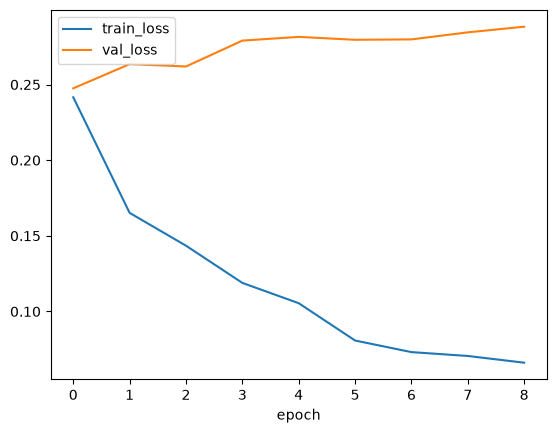

In [55]:
model_curves_df.plot(x='epoch', y=['train_loss', 'val_loss'])

# Let's run another experiment, this time adding some data augmentation.

In [56]:
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.5),          # geometric — syncs boxes via v2
    v2.ToDtype(torch.float32, scale=True),
])
test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),   # deterministic, no aug
])

In [57]:
aug_model = ModifiedFasterRCNN(
        detection_model=DETECTION_MODEL,
        optimizer=OPTIMIZER,
        learning_scheduler=SCHEDULER,
        early_stopper_class=EARLY_STOPPER,
        early_stopper_kwargs={'patience': 8},
        preprocessor_kwargs={'train_transforms': train_transforms,
                         'test_transforms': test_transforms}
    )

In [58]:
aug_model.replace_box_predictor(num_classes=2)

In [59]:
aug_loaders = aug_model.build_loaders(train_dataset, valid_dataset, test_dataset, batch_size=4, num_workers=2)

In [68]:
def show_dataloader_batch(loader, n=4, class_mapping=None, cols=2,
                          score_threshold=None):
    """Pull one batch from a detection DataLoader and plot images with boxes.

    Works with the detection collate_fn (batch = (images, targets)), where each
    image is a CxHxW float tensor in [0,1] and each target has 'boxes' [N,4]
    xyxy and 'labels' [N]. If targets also carry 'scores' (i.e. you passed in
    model predictions rather than ground truth), pass score_threshold to filter.

    class_mapping: optional {name: id} dict, inverted for readable labels.
    """
    id_to_name = {v: k for k, v in class_mapping.items()} if class_mapping else None

    # grab a single batch
    images, targets = next(iter(loader))
    n = min(n, len(images))

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i in range(n):
        img = images[i]
        target = targets[i]
        ax = axes[i]

        # image: CxHxW float [0,1] -> HxWxC numpy for imshow
        img_disp = img.detach().cpu().float().clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img_disp)

        # boxes: unwrap tv_tensors / move to plain cpu tensor
        boxes = torch.as_tensor(target['boxes']).detach().cpu()
        labels = target['labels'].detach().cpu()
        scores = target.get('scores', None)
        if scores is not None:
            scores = scores.detach().cpu()

        n_boxes = boxes.shape[0]
        title = f"sample {i} — {n_boxes} box(es)"
        if n_boxes == 0:
            title += "  [EMPTY]"

        for j in range(n_boxes):
            if score_threshold is not None and scores is not None:
                if scores[j] < score_threshold:
                    continue
            xmin, ymin, xmax, ymax = boxes[j].tolist()
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)

            lbl = labels[j].item()
            name = id_to_name.get(lbl, str(lbl)) if id_to_name else str(lbl)
            tag = name if scores is None else f"{name} {scores[j]:.2f}"
            ax.text(xmin, max(ymin - 4, 0), tag, color='black',
                    fontsize=9, backgroundcolor='lime')

        ax.set_title(title, fontsize=10)
        ax.axis('off')

    for k in range(n, len(axes)):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()

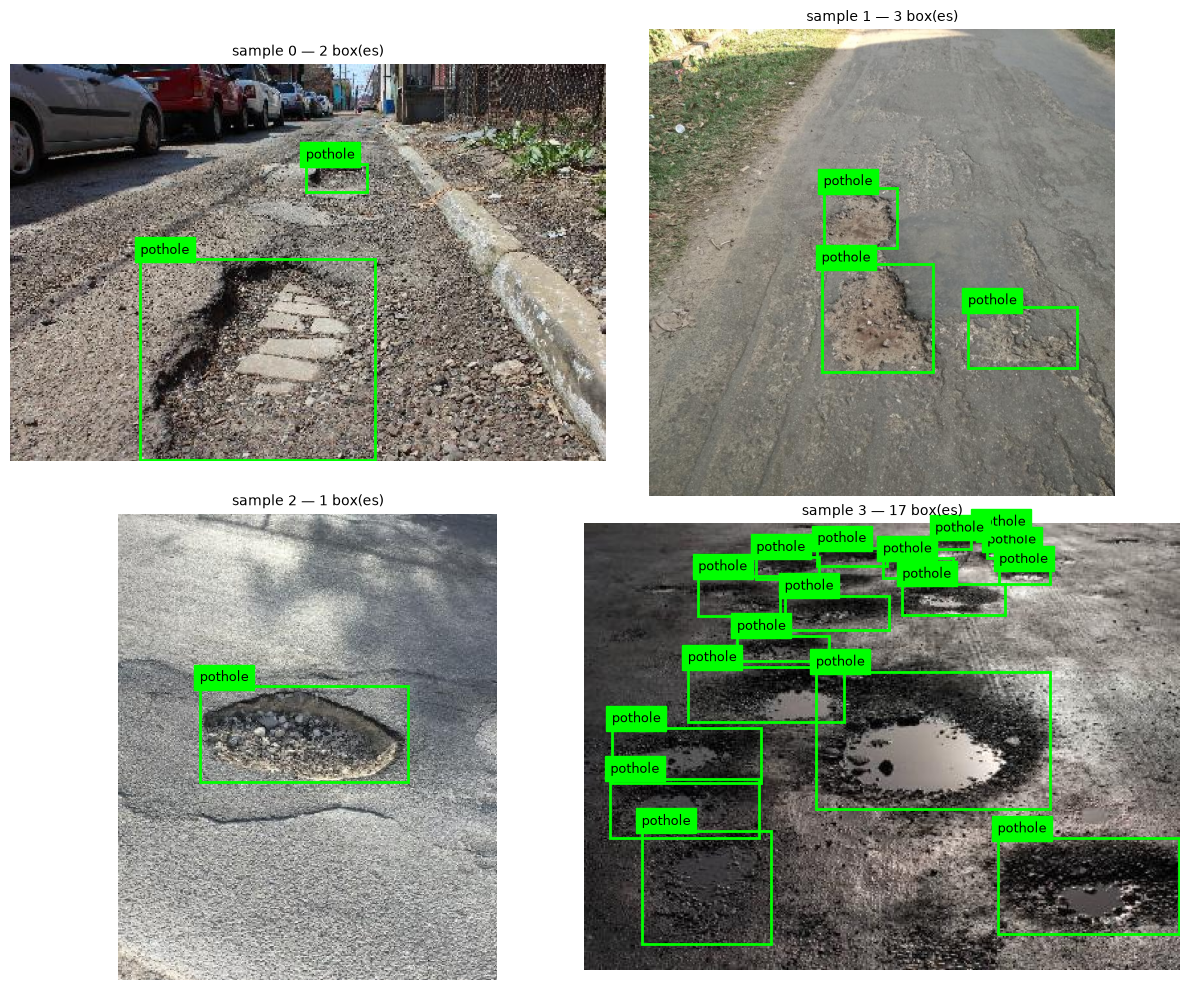

In [71]:
show_dataloader_batch(aug_loaders['train'], class_mapping = CLASS_NAMES)

# Discussion
That looks pretty good, I mainly wanted to see that flipping didn't make the potholes and boxes out of sync

In [72]:
aug_model.training_loop(train_loader=aug_loaders['train'],
                    val_loader=aug_loaders['val'],
                    device=device,
                    epochs=100,
                    optimizer__lr=0.005, 
                    optimizer__momentum=0.9,
                    optimizer__weight_decay=0.0005,
                    scheduler__mode='min', 
                    scheduler__patience=3,
                    calculate_map_interval=5,
                    print_every=5,
                    full_map_metrics=True)

Starting detection training for 100 epoch(s)
  trainable params: 41,076,761 | train batches/epoch: 107 | device: cuda

Epoch 1/100
  Epoch 1/100 batch 5/107 | loss 0.7959 | loss_classifier=0.085 loss_box_reg=0.212 loss_objectness=0.000 loss_rpn_box_reg=0.002
  Epoch 1/100 batch 10/107 | loss 0.6134 | loss_classifier=0.249 loss_box_reg=0.549 loss_objectness=0.003 loss_rpn_box_reg=0.032
  Epoch 1/100 batch 15/107 | loss 0.5516 | loss_classifier=0.067 loss_box_reg=0.092 loss_objectness=0.009 loss_rpn_box_reg=0.019
  Epoch 1/100 batch 20/107 | loss 0.4950 | loss_classifier=0.081 loss_box_reg=0.225 loss_objectness=0.006 loss_rpn_box_reg=0.017
  Epoch 1/100 batch 25/107 | loss 0.4476 | loss_classifier=0.055 loss_box_reg=0.070 loss_objectness=0.009 loss_rpn_box_reg=0.006
  Epoch 1/100 batch 30/107 | loss 0.4095 | loss_classifier=0.085 loss_box_reg=0.133 loss_objectness=0.007 loss_rpn_box_reg=0.004
  Epoch 1/100 batch 35/107 | loss 0.3819 | loss_classifier=0.152 loss_box_reg=0.184 loss_objectn

In [51]:
device

device(type='cuda')

Note: discovered a bug/typo after the fact where `aug_model` selected its best mAP epoch using `loaders` instead of `aug_loaders`. In practice this is okay because the validation set goes through only deterministic transformations, so `aug_loaders['val'] == loaders['val']`

In [73]:
aug_model.select_best_by_map(loaders['val'], device)
                                                                          

Selected checkpoint from epoch 9 (mAP=0.4990)


In [74]:
aug_model_curves_df = pd.DataFrame(aug_model.training_history)

In [75]:
aug_model_curves_df

,epoch,epoch_of_current_run,train_loss,val_loss,learning_rate,val_map,val_map_50,val_map_75
0,0,0,0.253311,0.275074,0.00500,NaN,NaN,NaN
1,1,1,0.188930,0.266812,0.00500,NaN,NaN,NaN
2,2,2,0.167064,0.259969,0.00500,NaN,NaN,NaN
3,3,3,0.151862,0.269675,0.00500,NaN,NaN,NaN
4,4,4,0.123227,0.259586,0.00500,0.482681,0.801791,0.528071
5,5,5,0.112942,0.269236,0.00500,NaN,NaN,NaN
6,6,6,0.099766,0.271710,0.00500,NaN,NaN,NaN
7,7,7,0.093496,0.313120,0.00500,NaN,NaN,NaN
8,8,8,0.084112,0.304076,0.00050,NaN,NaN,NaN
9,9,9,0.070012,0.304148,0.00050,0.498993,0.788016,0.566139


<Axes: xlabel='epoch'>

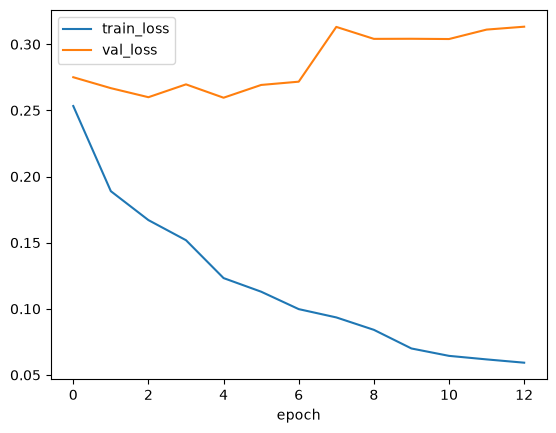

In [77]:
aug_model_curves_df.plot(x='epoch', y=['train_loss', 'val_loss'])

# Discussion

* We applied a random horizontal flip, a simple data augmentation exercise, and got a better val mAP!
* Let's try some additional augmentation 

In [78]:
train_tf_more = v2.Compose([
    v2.ToImage(),

    # --- geometric (box-syncing, all realistic for road scenes) ---
    v2.RandomHorizontalFlip(p=0.5),          # proven winner from last run
    v2.RandomIoUCrop(),                       # zoom/crop; detection-aware, keeps boxes
    v2.RandomZoomOut(fill=0, side_range=(1.0, 1.5)),  # simulates farther objects

    # --- photometric (pixel-only, cannot desync boxes) ---
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),

    # --- finalize ---
    v2.ClampBoundingBoxes(),                  # clip boxes to canvas after geometry
    v2.SanitizeBoundingBoxes(),               # drop boxes that got cropped to nothing
    v2.ToDtype(torch.float32, scale=True),
])

test_tf_more = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

In [80]:
aug_more_model = ModifiedFasterRCNN(
        detection_model=DETECTION_MODEL,
        optimizer=OPTIMIZER,
        learning_scheduler=SCHEDULER,
        early_stopper_class=EARLY_STOPPER,
        early_stopper_kwargs={'patience': 15},
        preprocessor_kwargs={'train_transforms': train_tf_more,
                         'test_transforms': test_tf_more}
    )

In [82]:
aug_more_model.replace_box_predictor(num_classes=2)

In [83]:
aug_more_loaders = aug_more_model.build_loaders(train_dataset, valid_dataset, test_dataset, batch_size=4, num_workers=2)

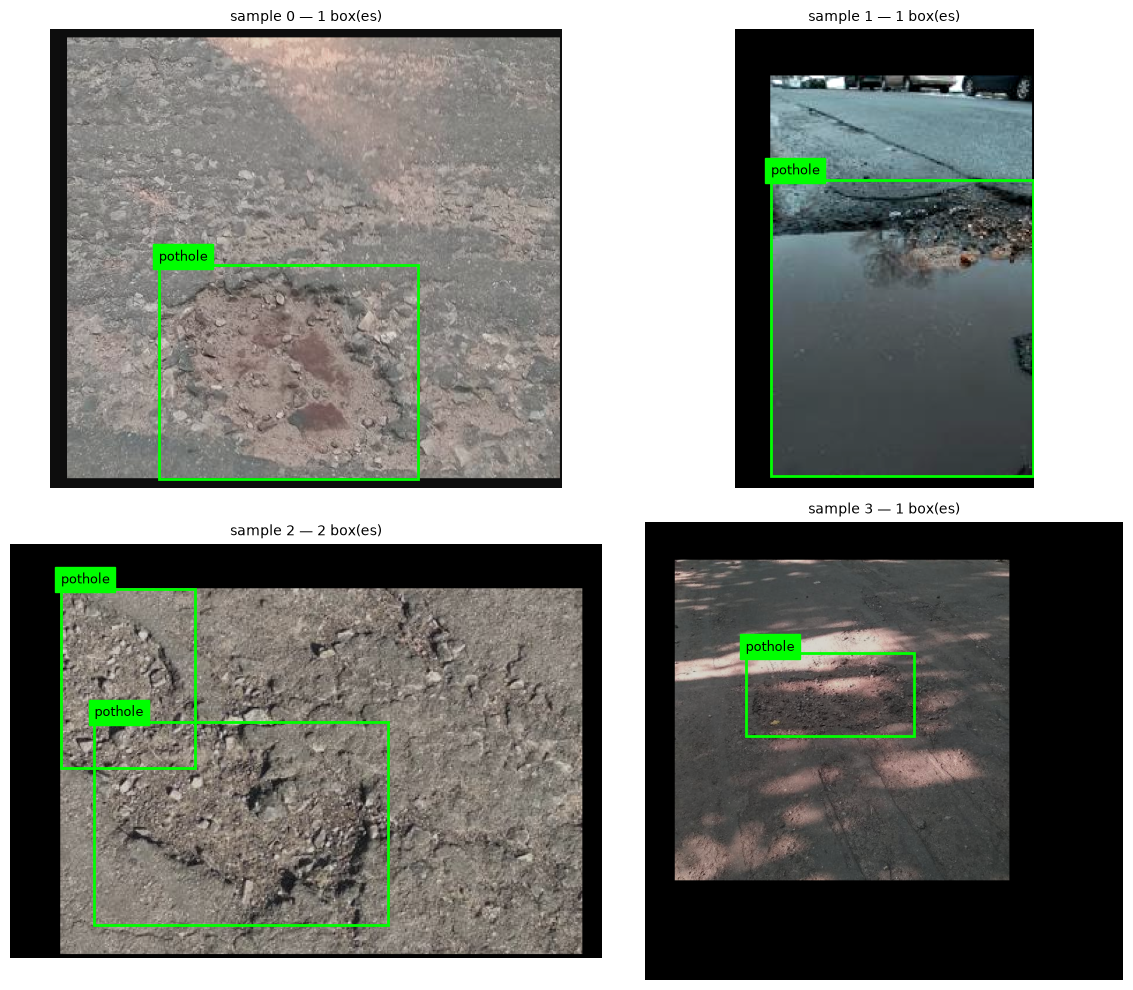

In [85]:
show_dataloader_batch(aug_more_loaders['train'], class_mapping = CLASS_NAMES)

In [87]:
aug_more_model.training_loop(train_loader=aug_more_loaders['train'],
                    val_loader=aug_more_loaders['val'],
                    device=device,
                    epochs=100,
                    optimizer__lr=0.005, 
                    optimizer__momentum=0.9,
                    optimizer__weight_decay=0.0005,
                    scheduler__mode='min', 
                    scheduler__patience=3,
                    calculate_map_interval=5,
                    print_every=5,
                    full_map_metrics=True)

Starting detection training for 100 epoch(s)
  trainable params: 41,076,761 | train batches/epoch: 107 | device: cuda

Epoch 1/100
  Epoch 1/100 batch 5/107 | loss 0.5807 | loss_classifier=0.204 loss_box_reg=0.363 loss_objectness=0.004 loss_rpn_box_reg=0.002
  Epoch 1/100 batch 10/107 | loss 0.4917 | loss_classifier=0.152 loss_box_reg=0.294 loss_objectness=0.003 loss_rpn_box_reg=0.004
  Epoch 1/100 batch 15/107 | loss 0.4280 | loss_classifier=0.131 loss_box_reg=0.288 loss_objectness=0.014 loss_rpn_box_reg=0.010
  Epoch 1/100 batch 20/107 | loss 0.3846 | loss_classifier=0.106 loss_box_reg=0.142 loss_objectness=0.026 loss_rpn_box_reg=0.005
  Epoch 1/100 batch 25/107 | loss 0.3764 | loss_classifier=0.113 loss_box_reg=0.260 loss_objectness=0.006 loss_rpn_box_reg=0.004
  Epoch 1/100 batch 30/107 | loss 0.3543 | loss_classifier=0.055 loss_box_reg=0.151 loss_objectness=0.006 loss_rpn_box_reg=0.003
  Epoch 1/100 batch 35/107 | loss 0.3392 | loss_classifier=0.060 loss_box_reg=0.106 loss_objectn

In [88]:
aug_more_model.select_best_by_map(aug_more_loaders['val'], device)
                                                                          

Selected checkpoint from epoch 8 (mAP=0.5529)


In [89]:
aug_more_model_curves_df = pd.DataFrame(aug_more_model.training_history)

In [90]:
aug_more_model_curves_df

,epoch,epoch_of_current_run,train_loss,val_loss,learning_rate,val_map,val_map_50,val_map_75
0,0,0,0.261021,0.259642,5.000000e-03,NaN,NaN,NaN
1,1,1,0.185342,0.248947,5.000000e-03,NaN,NaN,NaN
2,2,2,0.182419,0.239879,5.000000e-03,NaN,NaN,NaN
3,3,3,0.169882,0.243372,5.000000e-03,NaN,NaN,NaN
4,4,4,0.170860,0.245488,5.000000e-03,0.514390,0.824032,0.592600
5,5,5,0.167991,0.243150,5.000000e-03,NaN,NaN,NaN
6,6,6,0.164833,0.248847,5.000000e-04,NaN,NaN,NaN
7,7,7,0.151804,0.237380,5.000000e-04,NaN,NaN,NaN
8,8,8,0.148622,0.236372,5.000000e-04,NaN,NaN,NaN
9,9,9,0.139267,0.238634,5.000000e-04,0.551952,0.835909,0.651900


<Axes: xlabel='epoch'>

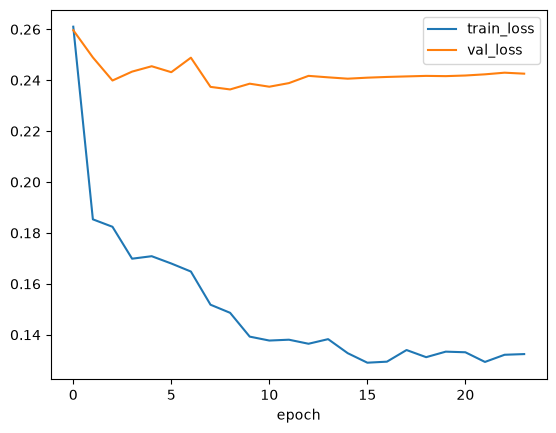

In [91]:
aug_more_model_curves_df.plot(x='epoch', y=['train_loss', 'val_loss'])

# Discussion

* Nice! We get our best mAP yet, by some margin. I think this is our winning model.
* Now we just need to evaluate it on the test set.

In [93]:
torch.save(aug_more_model.model.state_dict(), '/home/jovyan/work/aug_more_model.pt')

In [94]:
test_loader = aug_more_model.build_loader(test_dataset, is_train=False,
                                 batch_size=4, num_workers=2)

# full metrics: map, map_50, map_75 (+ the size-stratified breakdowns)
test_results = aug_more_model.evaluate_detections(test_loader, device, return_full=True)

print("=" * 50)
print("TEST SET RESULTS (held out, evaluated once)")
print("=" * 50)
for key in ['map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large']:
    if key in test_results:
        val = test_results[key]
        val = val.item() if torch.is_tensor(val) else val
        print(f"  {key:12s}: {val:.4f}")

TEST SET RESULTS (held out, evaluated once)
  map         : 0.4788
  map_50      : 0.7888
  map_75      : 0.5018
  map_small   : 0.2562
  map_medium  : 0.4515
  map_large   : 0.6251


# Discussion

* We see that there's roughly a 7-8 pp dropoff between the valid mAP and the test mAP. We definitely expected some dropoff, considering early stopping was based on val loss, and the final weights chosen (also, the final *experiment* chosen) optimized for val mAP.
* mAP50 suggests that the model does a pretty good job identifying roughly where a pothole is. It's more of an assessment of how well the model distinguishes between 'no pothole' and 'pothole somewhere around here', than a measure of how well the model draws a tight bounding box around the pothole. If we imagine a use case of using computer vision to alert a municipality that certain sections of roads need to be redone, I think this mAP50 metric might actually be the ideal one.
* Unsurprisingly, the model is much better at identifying large potholes versus small ones. We may consider specific data augmentation or architectural experiments to counter this weakness in the future.